# Context Offloading & Virtual File System

**Context Offloading** 기법을 활용하여 에이전트의 컨텍스트 윈도우를 효율적으로 관리하고, 가상 파일 시스템을 구축하는 방법을 다룹니다.

![](assets/agent_header_files.png)

**🏆 핵심 내용**

*   **Context Offloading**: 파일 시스템을 활용한 효율적인 컨텍스트 관리 전략
*   **Virtual File System**: LangGraph State 내 가상 파일 시스템 설계 및 구현
*   **File Tools**: `ls`, `read_file`, `write_file` 도구 개발 및 프롬프트 설계
*   **State & Reducer**: 파일 시스템 통합 및 Reducer를 통한 상태 병합 원리
*   **실습**: 연구 에이전트 예제를 통한 Context Offloading 적용

## Context 부하를 줄여주는 방법론: Filesystem 을 활용한 Context Offloading

**Context Offloading**은 복잡한 작업 시 급격히 증가하는 Context Window 문제를 해결하기 위해, 중요 정보를 파일 시스템에 저장하고 필요 시 로드하는 전략입니다.

***전체를 context에 담는 것 보다 조금씩 가져와서 원하는 내용을 찾는게 확률이 더 좋다***


*   **필요성**: 다수의 Tool 호출로 인한 Context 누적 및 비용 증가 방지
*   **활용 사례**:
    *   [Manus](https://manus.im/blog/Context-Engineering-for-AI-Agents-Lessons-from-Building-Manus): 메모리 관리 최적화
    *   [Hugging Face Open Deep Research](https://huggingface.co/blog/open-deep-research): 대규모 연구 작업 지원
    *   [Anthropic Multi-agent System](https://www.anthropic.com/engineering/multi-agent-research-system): Subagent 간 정보 왜곡 방지 및 효율적 정보 공유
*   **장점**:
    *   메모리 효율성 증대
    *   구조화된 결과물(코드, 보고서 등)의 안정적 보존
    *   장기 작업 시 중간 결과 유지 및 재활용 용이

In [2]:
# 프롬프트 출력 함수 호출을 위한 유틸리티 함수 임포트
from util.messages_in_jupyter import show_prompt

from deep_agents_from_scratch.prompts import (
    LS_DESCRIPTION_KOR,
    READ_FILE_DESCRIPTION_KOR,
    WRITE_FILE_DESCRIPTION_KOR,
)

# 파일 목록 조회도구 프롬프트
show_prompt(LS_DESCRIPTION_KOR)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  에이전트 상태에 저장된 가상 파일 시스템의 모든 파일을 나열합니다.                                              │
│                                                                                                                 │
│  에이전트 메모리에 현재 존재하는 파일을 보여줍니다. 다른 파일 작업 전에 방향을 잡고                             │
│  파일 구성을 인지하는 데 사용하십시오.                                                                          │
│                                                                                                                 │
│  매개변수는 필요 없습니다. ls()만 호출하면 사용 가능한 모든 파일을 볼 수 있습니다.                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [3]:
# 파일 내용 읽기도구 프롬프트
show_prompt(READ_FILE_DESCRIPTION_KOR)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  선택적 페이지네이션으로 가상 파일 시스템의 파일 내용을 읽습니다.                                               │
│                                                                                                                 │
│  이 도구는 줄 번호가 있는 파일 내용을 반환합니다(`cat -n`과 유사).                                              │
│  컨텍스트 오버플로를 피하기 위해 대용량 파일을 청크 단위로 읽는 것을 지원합니다.                                │
│                                                                                                                 │
│  매개변수:                                                                                                      │
│  - file_path (필수): 읽을 파일 경로                                                                             │
│  - offset (선택, 기본값=0): 읽기 시작 줄 번호                                                                   │
│  - limit (선택, 기본값=2000): 읽을 최대 줄 수                                                                   │
│                                                                                                                 │
│  기존 내용을 이해하기 위해 편집 전에 필수입니다. 편집하기 전에 항상 파일을 읽으십시오.                          │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [4]:
# 파일 쓰기도구 프롬프트
show_prompt(WRITE_FILE_DESCRIPTION_KOR)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  가상 파일 시스템에서 새 파일을 만들거나 기존 파일을 완전히 덮어씁니다.                                         │
│                                                                                                                 │
│  이 도구는 새 파일을 만들거나 파일 전체 내용을 교체합니다.                                                      │
│  최초 파일 생성이나 전체 재작성에 사용하십시오. 파일은 에이전트 상태에 영구 저장됩니다.                         │
│                                                                                                                 │
│  매개변수:                                                                                                      │
│  - file_path (필수): 파일을 생성/덮어쓸 경로                                                                    │
│  - content (필수): 파일에 쓸 전체 내용                                                                          │
│                                                                                                                 │
│  중요: 파일 전체 내용을 대체합니다.                                                                             │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [5]:
# Full prompt
from deep_agents_from_scratch.prompts import FILE_USAGE_INSTRUCTIONS_KOR, SIMPLE_RESEARCH_INSTRUCTIONS_KOR


INSTRUCTIONS = (
    FILE_USAGE_INSTRUCTIONS_KOR + "\n\n" + "=" * 80 + "\n\n" + SIMPLE_RESEARCH_INSTRUCTIONS_KOR
)
show_prompt(INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  컨텍스트를 유지하고 저장하는 데 도움이 되는 가상 파일 시스템에 접근할 수 있습니다.                             │
│                                                                                                                 │
│  ## 워크플로 절차                                                                                               │
│  1. **Orient**: 작업을 시작하기 전에 ls()로 기존 파일을 확인하십시오                                            │
│  2. **Save**: write_file()로 사용자 요청을 저장하여 나중에 보관할 수 있게 하십시오                              │
│  3. **Research**: 연구를 진행하십시오. 검색 도구가 파일을 작성합니다.                                           │
│  4. **Read**: 수집한 출처에 만족하면 파일을 읽고 사용자 질문에 직접 답하십시오.                                 │
│                                                                                                                 │
│                                                                                                                 │
│  ================================================================================                               │
│                                                                                                                 │
│  중요: web_search 도구를 한 번만 호출하고, 도구가 제공한 결과를 사용하여 사용자 질문에 답하십시오. 답변은       │
│  한국어로 작성하십시오.                                                                                         │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

컨텍스트 유지 및 저장을 위한 가상 파일시스템 접근 권한 보유

*필수 워크플로우 프로세스 (반드시 순서대로 수행)*

**⚠️ 1단계 - 탐색 (필수 첫 단계):**

- **필수**: 다른 파일 작업이나 작업 시작 전 반드시 ls()를 첫 번째 도구 호출로 실행
- **생략 금지**: 시스템에 존재하는 파일 파악을 위한 필수 단계
- **시점**: 사용자 요청 수신 즉시, 다른 도구 호출 전 ls() 호출
- **이유**: 기존 파일 파악으로 중복 작업 방지 및 접근 방식 체계화

**2단계 - 저장:**

- write_file()로 사용자 요청 저장하여 추후 참조용으로 보관

**3단계 - 읽기:**

- 수집된 소스에 만족하면 저장된 파일 읽고 사용자 질문에 직접 답변

*주요 참고사항*

- **탐색 단계 생략 금지** - 파일이 없다고 예상되더라도 항상 ls() 먼저 호출
- 탐색 단계로 현재 상태 파악 및 효과적인 작업 계획 수립 가능
- 탐색 생략 시 중요한 컨텍스트 누락 또는 중복 파일 생성 위험

---

web_search 도구로 정보 검색 후 도구가 제공한 결과를 사용하여 사용자 질문에 답변할 것.

## 연구 에이전트(Research Agent)

가상 파일 시스템과 도구를 활용하여 **Context Offloading**을 적용한 연구 에이전트(Research Agent)를 생성합니다.

*   **시나리오**: 사용자 요청 저장 → 파일 읽기 → 답변 생성
*   **활용성**:
    *   **Long-running Agent**: 장기 작업 시 중요 정보 보존
    *   **Context Engineering**: 정보 압축 및 삭제 대비 중요 데이터 백업
*   **참고**: [Anthropic Multi-agent System](https://www.anthropic.com/engineering/multi-agent-research-system)의 파일 기반 정보 복원 전략

### 초기 상태 및 실행 흐름

*   **초기 상태**: 빈 `files` 상태로 시작
*   **실행 흐름**: 사용자 요청 수신 → 파일 생성 및 저장 → 정보 활용
*   **의의**: 실제 서비스 환경과 유사한 **Context Offloading** 패턴 실습

이제 앞서 구현한 가상 파일 시스템과 파일 도구를 실제로 활용해보겠습니다. 간단한 연구 에이전트 예제를 통해, 사용자의 요청을 파일로 저장한 뒤, 해당 파일을 다시 읽어 답변하는 과정을 실습합니다.

이러한 방식은 특히 **장기적인 에이전트 작업(long-running agent trajectories)** 에서 매우 유용하게 활용됩니다. 본 예제에서는 모든 정보가 context에 쉽게 유지되지만, 실제 서비스 환경이나 복잡한 에이전트 시스템에서는 context의 크기가 빠르게 증가하거나 일부 정보가 압축 또는 삭제될 수 있습니다. 이때, 중요한 정보를 압축 전에 파일로 저장하고, 필요할 때 다시 불러오는 전략은 **스마트한 context 관리(context engineering)** 방법으로 평가받고 있습니다.

실제로, Anthropic의 [multi-agent research system](https://www.anthropic.com/engineering/multi-agent-research-system#:~:text=Long%2Dhorizon%20conversation,across%20extended%20interactions.)에서도 이러한 파일 기반 정보 저장 및 복원이 장기 대화나 복잡한 작업 흐름에서 효과적으로 활용되고 있습니다.

이제, 가상 파일 시스템을 활용한 연구 에이전트 예제를 통해 context offloading의 실제 적용 방법을 살펴보겠습니다.

### 실행 결과 분석

*   **파일 저장 확인**: 가상 파일 시스템에 사용자 요청이 정상적으로 저장됨
*   **활용**: `read_file`을 통해 언제든 정보 조회 및 활용 가능
*   **결론**: 파일 기반 컨텍스트 관리를 통해 정보 안정성 확보 및 메모리 최적화 달성

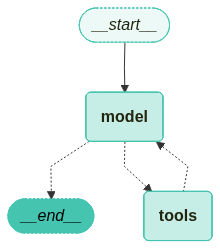

In [6]:
from deep_agents_from_scratch.deep_agent_context_offloading_graph import DeepAgentContextOffloadingGraph
from util.chat_model_enums import LangChainChatModel

workflow = DeepAgentContextOffloadingGraph(agent_files_dir="./data", model=LangChainChatModel.OPENAI_GPT_5)

workflow.show_graph()

## 실행 및 결과 확인

In [7]:
from util.messages_in_jupyter import format_messages

result = workflow.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Model Context Protocol (MCP) 의 개요에 대해서 설명하세요.",
            }
        ],
        "files": {},
    }
)

# 결과 확인
format_messages(result["messages"])


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================
Tool Calls:
  ls (call_fx7waZdNPqDaoq6M36Tiw4sw)
 Call ID: call_fx7waZdNPqDaoq6M36Tiw4sw
  Args:

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================= Tool Message =================================
Name: ls

["requests/original_request_ko.txt", "research/mcp_overview_ko.md"]

🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================
Tool Calls:
  read_file (call_ji2ZALCawMfR0ATtj6wQMbdi)
 Call ID: call_ji2ZALCawMfR0ATtj6wQMbdi
  Args:
    file_path: requests/original_request_ko.txt

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================= Tool Message =================================
Name: read_file

     1	사용자 요청: Model Context Protocol (MCP) 의 개요에 대해서 설명하세요.

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Model Context Protocol (MCP) 의 개요에 대해서 설명하세요.                                                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: ls                                                                                                │
│    Args: {}                                                                                                     │
│    ID: call_fx7waZdNPqDaoq6M36Tiw4sw                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ ["requests/original_request_ko.txt", "research/mcp_overview_ko.md"]                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: read_file                                                                                         │
│    Args: {                                                                                                      │
│   "file_path": "requests/original_request_ko.txt"                                                               │
│ }                                                                                                               │
│    ID: call_ji2ZALCawMfR0ATtj6wQMbdi                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_file                                                                                        │
│    Args: {                                                                                                      │
│   "file_path": "requests/original_request_ko.txt",                                                              │
│   "content": "사용자 요청: Model Context Protocol (MCP) 의 개요에 대해서 설명하세요."                           │
│ }                                                                                                               │
│    ID: call_5aINVy0aOkKuuXFh9rk554pz                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated file requests/original_request_ko.txt (saved to                                                         │
│ /Users/jyuka/workspace/LangGraph-Edu/deep_agents_from_scratch/notebooks/data/requests/original_request_ko.txt)  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: web_search                                                                                        │
│    Args: {                                                                                                      │
│   "query": "Model Context Protocol (MCP) overview Anthropic 개요 무엇인가"                                      │
│ }                                                                                                               │
│    ID: call_sOmNheJFhyqd5rjVu1gXcEM0                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 모델 컨텍스트 프로토콜(MCP)은 Anthropic이 개발한 개방형 표준 프로토콜로,                                        │
│ AI 모델과 도구, 데이터베이스, 기타 서비스와 같은 외부 시스템 간의 원활한 통합을 가능하게 합니다.                │
│ 이는 표준화된 통신 계층 역할을 하여 AI 모델이 다양한 출처의 데이터에 일관되고 효율적인 방식으로 접근하고 활용할 │
│ 수 있도록 합니다.                                                                                               │
│ 본질적으로 MCP는 데이터 교환을 위한 통합 언어를 제공함으로써 AI 어시스턴트를 외부 서비스에 연결하는 과정을      │
│ 단순화합니다.                                                                                                   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ 모델 컨텍스트 프로토콜(Model Context Protocol, MCP) 개요                                                        │
│                                                                                                                 │
│ - 정의: MCP는 Anthropic이 개발한 개방형 표준 프로토콜로, AI 모델과 외부 시스템(도구, 데이터베이스, 기타 서비스) │
│ 간을 쉽게 연결해 주는 통신 규격입니다.                                                                          │
│ - 역할: 표준화된 통신 계층으로 동작하여, AI 모델이 다양한 출처의 데이터를 일관되고 효율적으로 접근·활용할 수    │
│ 있게 합니다.                                                                                                    │
│ - 목적: 데이터 교환을 위한 “공통 언어”를 제공해, AI 어시스턴트를 각종 외부 서비스에 연동하는 과정을             │
│ 단순화합니다.                                                                                                   │
│                                                                                                                 │
│ 핵심 포인트                                                                                                     │
│ - 개방형 표준: 특정 벤더나 구현에 종속되지 않도록 설계됨                                                        │
│ - 통합 용이성: 도구·데이터베이스·서비스 등 다양한 외부 시스템과의 연결을 쉽게 지원                              │
│ - 일관성과 효율성: 여러 데이터 소스를 동일한 방식으로 다루고 처리 효율을 높임                                   │
│ - 단순화: 외부 서비스 연동 전반의 복잡도를 낮춰 개발·운영 부담을 줄임                                           │
│                                                                                                                 │
│ 적용 예시                                                                                                       │
│ - AI 어시스턴트가 회사 내부 데이터베이스를 조회하거나, 특정 도구를 호출해 작업을 수행하고, 외부 SaaS API와      │
│ 데이터를 주고받는 시나리오에서 MCP를 통해 일관된 방식으로 통신하고 통합할 수 있습니다.                          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

가상 파일 시스템에 파일이 정상적으로 저장된 것을 확인할 수 있습니다.  
이렇게 저장된 파일은 이후 에이전트가 필요할 때 언제든지 `read_file` 도구를 통해 내용을 조회하거나, 추가적인 정보를 기록하는 데 활용할 수 있습니다.  
이러한 파일 기반의 컨텍스트 관리 방식은 복잡한 작업 흐름에서도 중요한 정보를 안정적으로 보존하고, 에이전트의 메모리 사용을 효율적으로 최적화하는 데 큰 도움이 됩니다.

모의 파일 시스템에 파일이 저장된 것을 확인할 수 있습니다.

In [8]:
# 에이전트 실행 결과에서 가상 파일 시스템의 현재 상태(파일 목록 및 내용) 조회
print(workflow.file_store.list_files())

['requests/original_request_ko.txt', 'research/mcp_overview_ko.md']
